**CUSTOMER CHURN PREDICTION**

**Project Objective**

The objective of this project is to predict whether a customer is likely to churn based on their information, services, contract details, and billing information.

The project uses machine learning classification models to identify patterns associated with customer churn and provide insights that can help businesses improve customer retention.

In [ ]:
## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
## 2. Load Dataset

In [2]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
## 3. Data Understanding

In [3]:
df.tail()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
## 4. Data Cleaning

In [8]:
df['TotalCharges'].str.strip().eq('').sum()

np.int64(11)

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [11]:
df[df['TotalCharges'].isnull()]['tenure']

,tenure
488,0
753,0
936,0
1082,0
1340,0
3331,0
3826,0
4380,0
5218,0
6670,0


In [12]:
df=df.dropna(subset=['TotalCharges'])

In [13]:
df.shape

(7032, 21)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

,0
customerID,7032
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,72
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [16]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [17]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [18]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [19]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [20]:
df=df.drop('customerID', axis=1)

In [21]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


In [22]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.421502
Yes,26.578498


In [ ]:
## 5. Exploratory Data Analysis (EDA)

In [ ]:
### 5.1 Numerical Features

<Axes: xlabel='Churn', ylabel='count'>

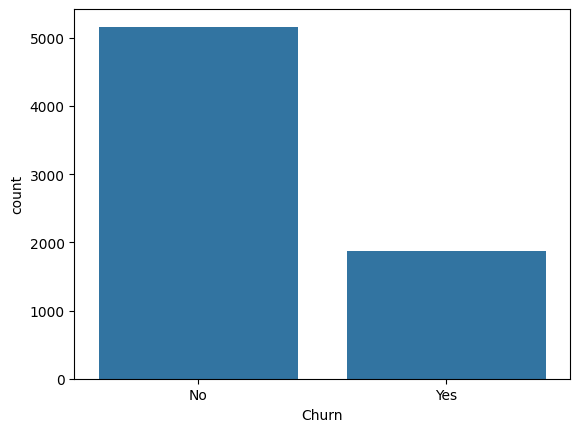

In [23]:
sns.countplot(x='Churn', data=df)

In [24]:
df['tenure'].describe()

,tenure
count,7032.000000
mean,32.421786
std,24.545260
min,1.000000
25%,9.000000
50%,29.000000
75%,55.000000
max,72.000000


In [25]:
df[['MonthlyCharges','TotalCharges']].describe()

,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000
mean,64.798208,2283.300441
std,30.085974,2266.771362
min,18.250000,18.800000
25%,35.587500,401.450000
50%,70.350000,1397.475000
75%,89.862500,3794.737500
max,118.750000,8684.800000


In [26]:
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


In [27]:
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


In [28]:
df.groupby('Churn')['TotalCharges'].mean()

,TotalCharges
Churn,
No,2555.344141
Yes,1531.796094


In [29]:
df.groupby('Churn')['Contract'].value_counts()

Churn  Contract      
No     Month-to-month    2220
       Two year          1637
       One year          1306
Yes    Month-to-month    1655
       One year           166
       Two year            48
Name: count, dtype: int64

In [30]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)*100

Contract        Churn
Month-to-month  No       57.290323
                Yes      42.709677
One year        No       88.722826
                Yes      11.277174
Two year        No       97.151335
                Yes       2.848665
Name: proportion, dtype: float64

In [31]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)*100

InternetService  Churn
DSL              No       81.001656
                 Yes      18.998344
Fiber optic      No       58.107235
                 Yes      41.892765
No               No       92.565789
                 Yes       7.434211
Name: proportion, dtype: float64

In [32]:
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)*100

PaymentMethod              Churn
Bank transfer (automatic)  No       83.268482
                           Yes      16.731518
Credit card (automatic)    No       84.746877
                           Yes      15.253123
Electronic check           No       54.714588
                           Yes      45.285412
Mailed check               No       80.798005
                           Yes      19.201995
Name: proportion, dtype: float64

In [33]:
df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True)*100

SeniorCitizen  Churn
0              No       76.349745
               Yes      23.650255
1              No       58.318739
               Yes      41.681261
Name: proportion, dtype: float64

In [ ]:
### 5.2 Categorical Features

<Axes: xlabel='Contract', ylabel='count'>

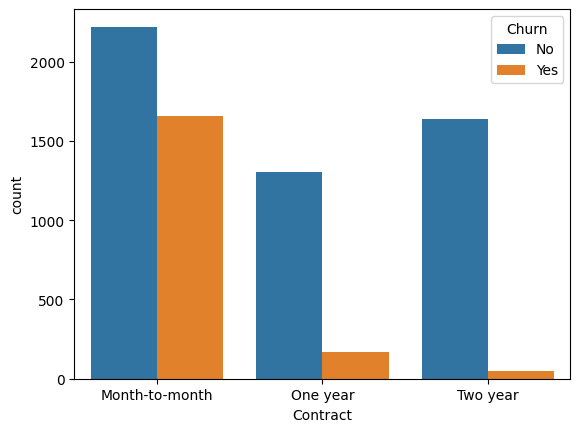

In [34]:
sns.countplot(x='Contract',hue='Churn',data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

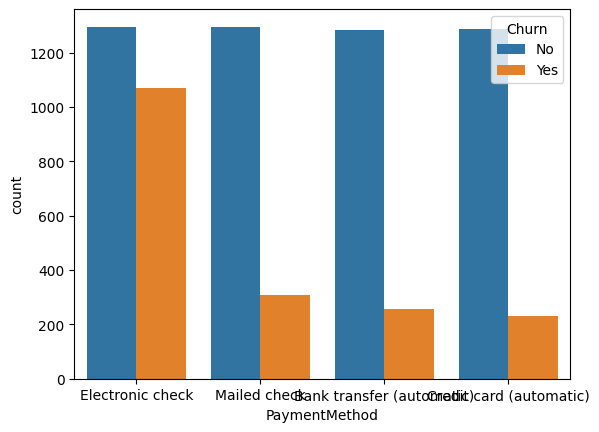

In [35]:
sns.countplot(x='PaymentMethod',hue='Churn',data=df)

<Axes: xlabel='InternetService', ylabel='count'>

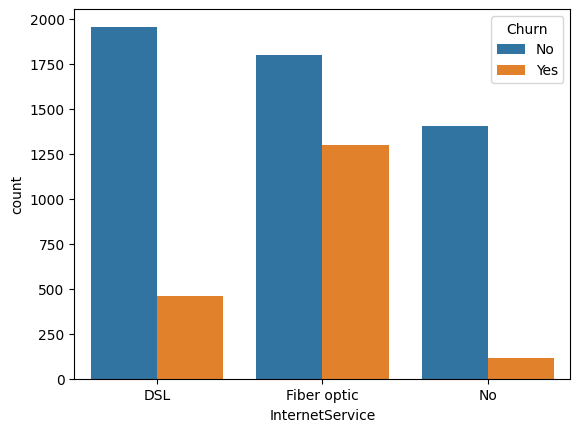

In [36]:
sns.countplot(x='InternetService',hue='Churn',data=df)

<Axes: xlabel='SeniorCitizen', ylabel='count'>

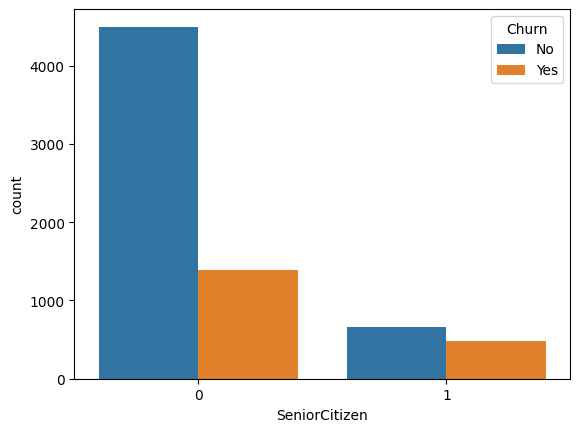

In [37]:
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)

<Axes: xlabel='gender', ylabel='count'>

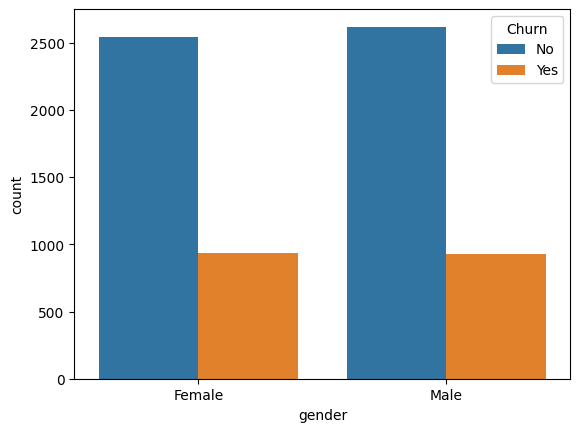

In [38]:
sns.countplot(x='gender',hue='Churn',data=df)

<Axes: xlabel='Churn', ylabel='tenure'>

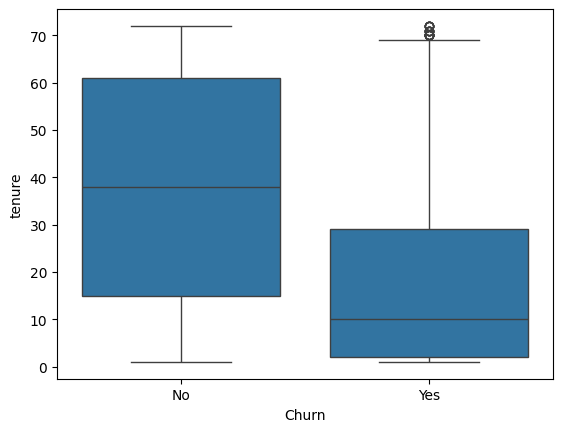

In [39]:
sns.boxplot(x='Churn',y='tenure',data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

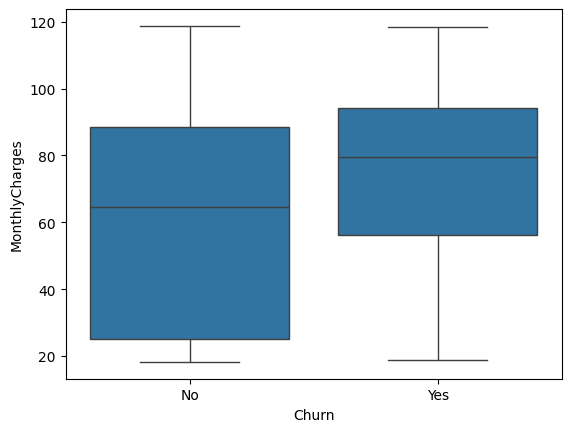

In [40]:
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

In [ ]:
## 6. Data Preprocessing

In [ ]:
### 6.1 Separate X and y

In [41]:
x = df.drop('Churn',axis=1)

In [42]:
y = df['Churn']

In [43]:
x.shape,y.shape

((7032, 19), (7032,))

In [ ]:
### 6.2 Encode categorical variables

In [44]:
y=y.map({'Yes':1,'No':0})

In [45]:
categorical = x.select_dtypes(include='object').columns
numerical = x.select_dtypes(exclude='object').columns

In [46]:
x = pd.get_dummies(x,columns=categorical,drop_first=True)

In [ ]:
 ### 6.2 Scale numerical variables

In [47]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x[numerical]=scaler.fit_transform(x[numerical])


In [ ]:
## 7. Train-Test Split

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [49]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((5625, 30), (1407, 30), (5625,), (1407,))

In [ ]:
## 8. Model Building

In [ ]:
### 8.1 Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [51]:
model.fit(x_train,y_train)

LogisticRegression()

In [52]:
y_pred=model.predict(x_test)

In [53]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7874911158493249

In [54]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [55]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[915, 118],
       [181, 193]])

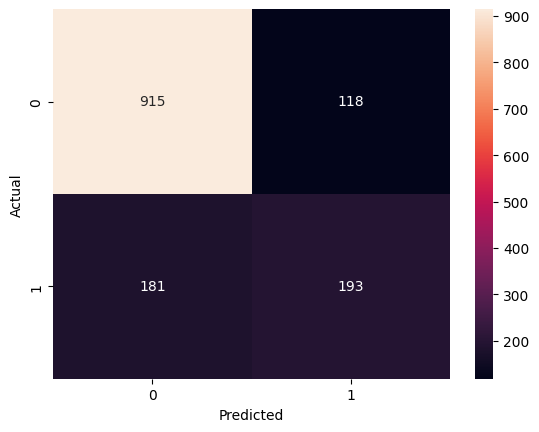

In [56]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
### 8.2 Decision Tree

In [57]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [58]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [59]:
y_pred=model.predict(x_test)

In [60]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7114427860696517

In [61]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1033
           1       0.46      0.51      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407



In [62]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[810, 223],
       [183, 191]])

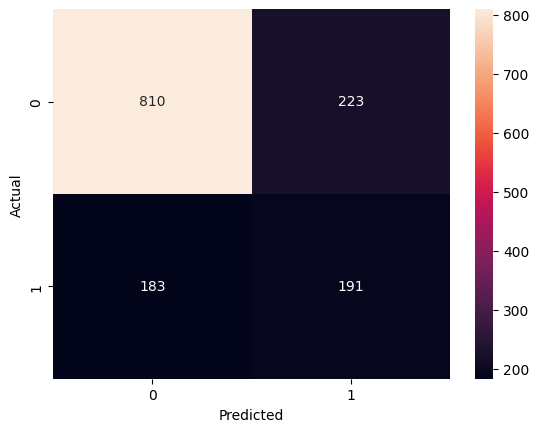

In [63]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
### 8.3 Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [65]:
model.fit(x_train,y_train)

RandomForestClassifier()

In [66]:
y_pred=model.predict(x_test)

In [67]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7853589196872779

In [68]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [69]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[931, 102],
       [200, 174]])

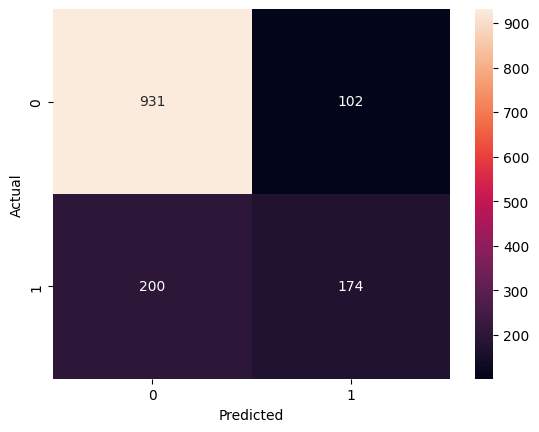

In [70]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
### 8.4 XGBoost

In [71]:
from xgboost import XGBClassifier
model = XGBClassifier()

In [72]:
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [73]:
y_pred=model.predict(x_test)

In [74]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.7683013503909026

In [75]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1033
           1       0.58      0.48      0.52       374

    accuracy                           0.77      1407
   macro avg       0.70      0.68      0.68      1407
weighted avg       0.76      0.77      0.76      1407



In [76]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
cm

array([[903, 130],
       [196, 178]])

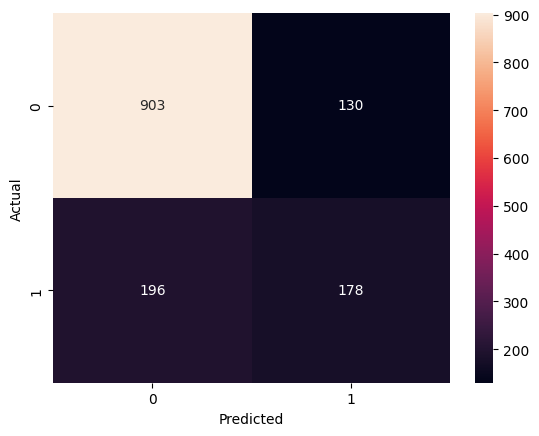

In [77]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
## 9. Feature Importance

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [79]:
importance = rf_model.feature_importances_

In [80]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance
})

In [81]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [82]:
feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.193409
2,MonthlyCharges,0.169758
1,tenure,0.167572
10,InternetService_Fiber optic,0.039999
28,PaymentMethod_Electronic check,0.035016
13,OnlineSecurity_Yes,0.028905
25,Contract_Two year,0.028618
4,gender_Male,0.026971
19,TechSupport_Yes,0.025829
26,PaperlessBilling_Yes,0.025044


In [ ]:
### 9.1 Feature Importance graph

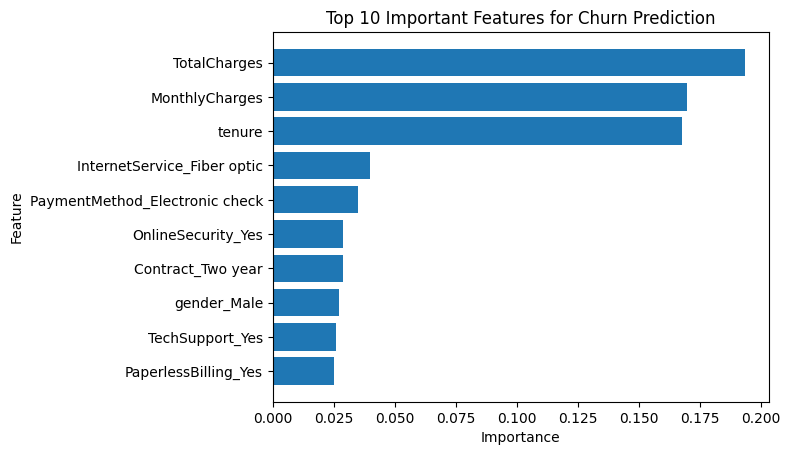

In [83]:
plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features for Churn Prediction')
plt.gca().invert_yaxis()

plt.show()

## 10. Business Insights

### 1. Contract Type
Month-to-month customers show substantially higher churn compared with customers on one-year and two-year contracts.

### 2. Customer Tenure
Churned customers have a much lower median tenure (10 months) compared with non-churned customers (38 months), indicating higher churn among newer customers.

### 3. Monthly Charges
Churned customers have a higher median monthly charge (approximately 80) compared with non-churned customers (approximately 65).


### 4. Internet Service
Fiber optic customers show a noticeably higher churn rate compared with DSL and customers without internet service.

### 5. Payment Method
Electronic check users show substantially more churn compared with customers using other payment methods.

### 6. Senior Citizen
Senior citizens have a higher churn proportion compared with non-senior customers.

### 7. Gender
Male and female customers show very similar churn patterns, suggesting that gender provides relatively little useful information for predicting churn.

# 11. Conclusion

### In this project, machine learning classification models were used to predict customer churn. The dataset was cleaned, explored, and preprocessed before training Logistic Regression, Decision Tree, Random Forest, and XGBoost models.

### The models were evaluated using accuracy, precision, recall, F1-score, and confusion matrices. The analysis also identified important factors associated with customer churn, including tenure, monthly charges, total charges, contract type, internet service, and payment method.

### The findings can help businesses identify customers who may be more likely to churn and focus their customer retention efforts on higher risk groups.